# INSURANCE CLAIM FRAUD DETECTION PROJECT

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
#Imbalance Handling

from imblearn.over_sampling import SMOTE

In [6]:
#Models

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [7]:
#Evaluation Metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [8]:
#Save Model

import joblib

In [9]:
#LOAD DATASET
data = pd.read_csv('fraud_insurance_claims.csv')
data

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17 00:00:00,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27 00:00:00,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06 00:00:00,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25 00:00:00,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06 00:00:00,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16 00:00:00,OH,500/1000,1000,1310.80,0,431289,...,1,?,87200,17440,8720,61040,Honda,Accord,2006,N
996,285,41,186934,2014-01-05 00:00:00,IL,100/300,1000,1436.79,0,608177,...,3,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N
997,130,34,918516,2003-02-17 00:00:00,OH,250/500,500,1383.49,3000000,442797,...,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N
998,458,62,533940,2011-11-18 00:00:00,IL,500/1000,2000,1356.92,5000000,441714,...,1,YES,46980,5220,5220,36540,Audi,A5,1998,N


In [10]:
#Display first 5 rows

data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17 00:00:00,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27 00:00:00,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06 00:00:00,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25 00:00:00,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06 00:00:00,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [11]:
#Dataset Shape

print("Dataset Shape:", data.shape)

Dataset Shape: (1000, 39)


In [12]:
#Dataset Information

print("\nDataset Info:\n")
print(data.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  ins

In [13]:
data.describe

<bound method NDFrame.describe of      months_as_customer  age  policy_number     policy_bind_date policy_state  \
0                   328   48         521585  2014-10-17 00:00:00           OH   
1                   228   42         342868  2006-06-27 00:00:00           IN   
2                   134   29         687698  2000-09-06 00:00:00           OH   
3                   256   41         227811  1990-05-25 00:00:00           IL   
4                   228   44         367455  2014-06-06 00:00:00           IL   
..                  ...  ...            ...                  ...          ...   
995                   3   38         941851  1991-07-16 00:00:00           OH   
996                 285   41         186934  2014-01-05 00:00:00           IL   
997                 130   34         918516  2003-02-17 00:00:00           OH   
998                 458   62         533940  2011-11-18 00:00:00           IL   
999                 456   60         556080  1996-11-11 00:00:00           

In [14]:
print("\nMissing Values:\n")
print(data.isnull().sum())


Missing Values:

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries               

In [15]:
print("\nDuplicate Rows:", data.duplicated().sum())


Duplicate Rows: 0


In [16]:
print("\nUnique Values:\n")
print(data.nunique())


Unique Values:

months_as_customer              391
age                              46
policy_number                  1000
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
umbrella_limit                   11
insured_zip                     995
insured_sex                       2
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital-gains                   338
capital-loss                    354
incident_date                    60
incident_type                     4
collision_type                    4
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_da

In [17]:
#identify coloumns types
print("\nColumn Data Types:\n")
print(data.dtypes)



Column Data Types:

months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
inci

In [18]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [19]:
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Columns:\n", numerical_cols)
print("\nCategorical Columns:\n", categorical_cols)


Numerical Columns:
 ['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

Categorical Columns:
 ['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


In [20]:


print("\nFraud Distribution:\n")
print(data['fraud_reported'].value_counts())


Fraud Distribution:

fraud_reported
N    753
Y    247
Name: count, dtype: int64


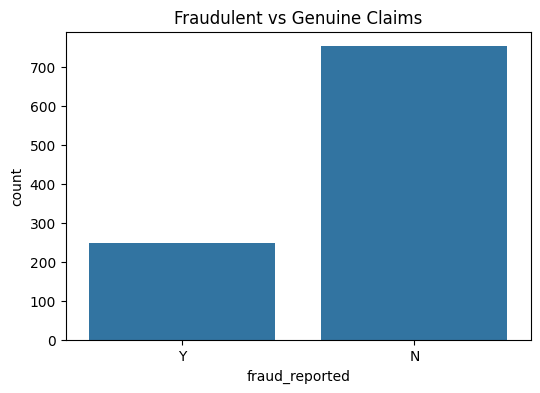

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_reported', data=data)
plt.title("Fraudulent vs Genuine Claims")
plt.show()

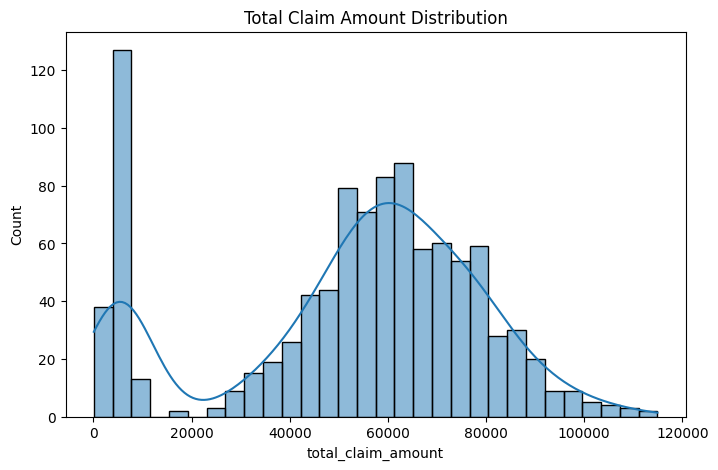

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data['total_claim_amount'], bins=30, kde=True)
plt.title("Total Claim Amount Distribution")
plt.show()

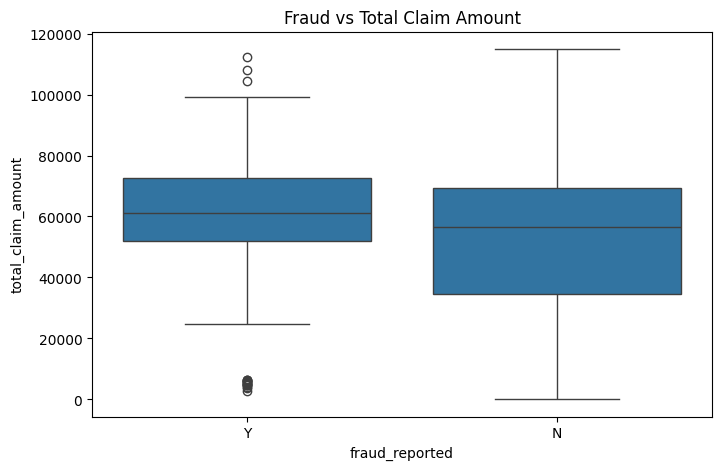

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=data)
plt.title("Fraud vs Total Claim Amount")
plt.show()

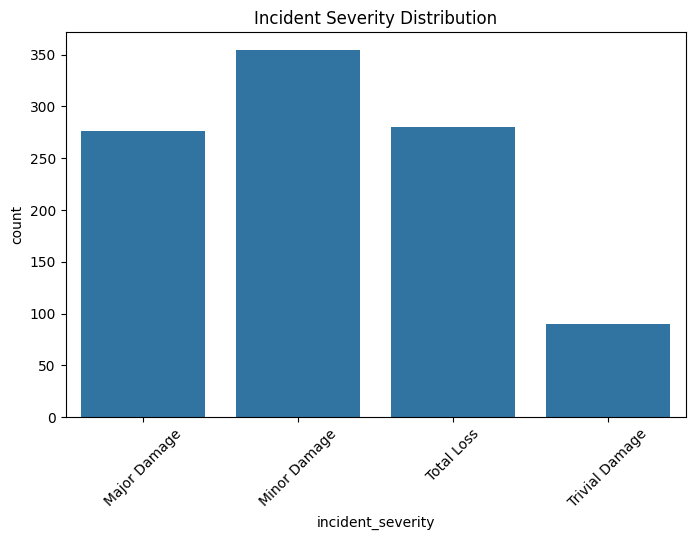

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='incident_severity', data=data)
plt.xticks(rotation=45)
plt.title("Incident Severity Distribution")
plt.show()

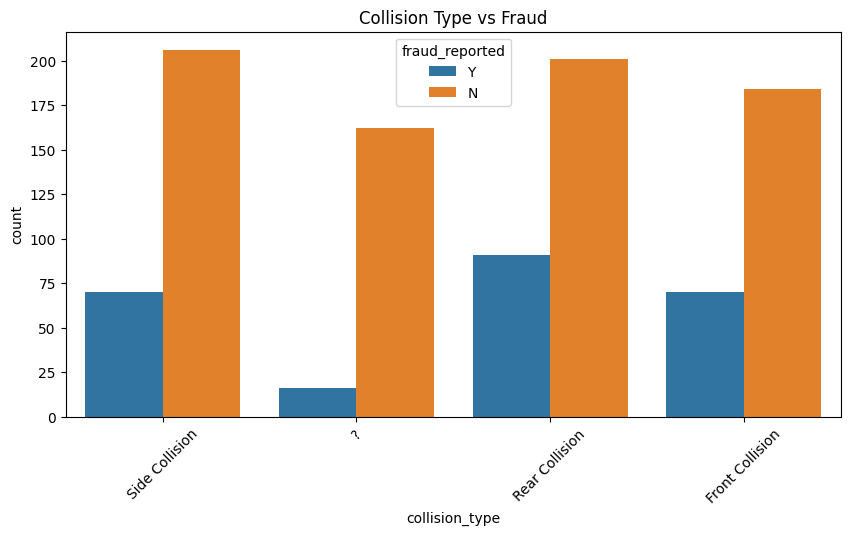

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x='collision_type', hue='fraud_reported', data=data)
plt.xticks(rotation=45)
plt.title("Collision Type vs Fraud")
plt.show()

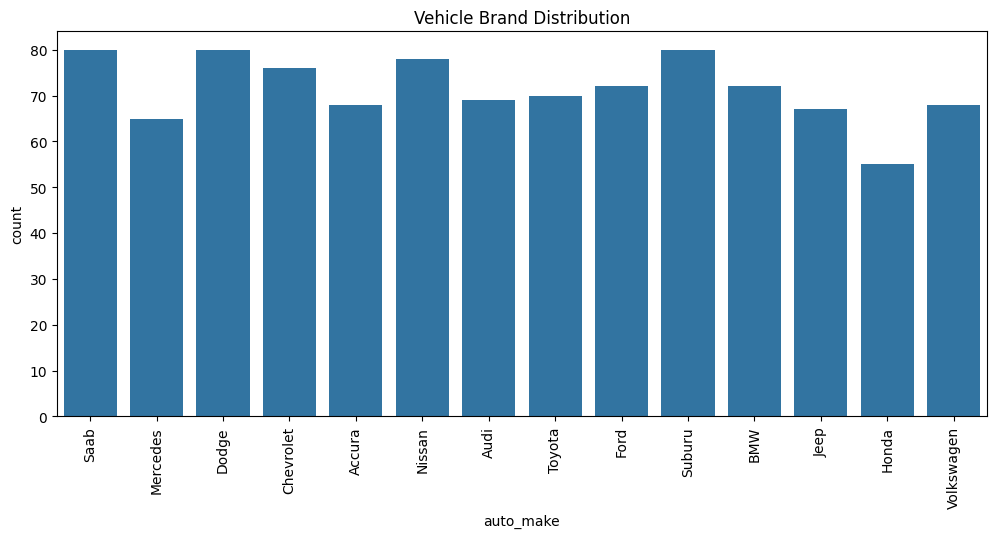

In [26]:
plt.figure(figsize=(12,5))
sns.countplot(x='auto_make', data=data)
plt.xticks(rotation=90)
plt.title("Vehicle Brand Distribution")
plt.show()

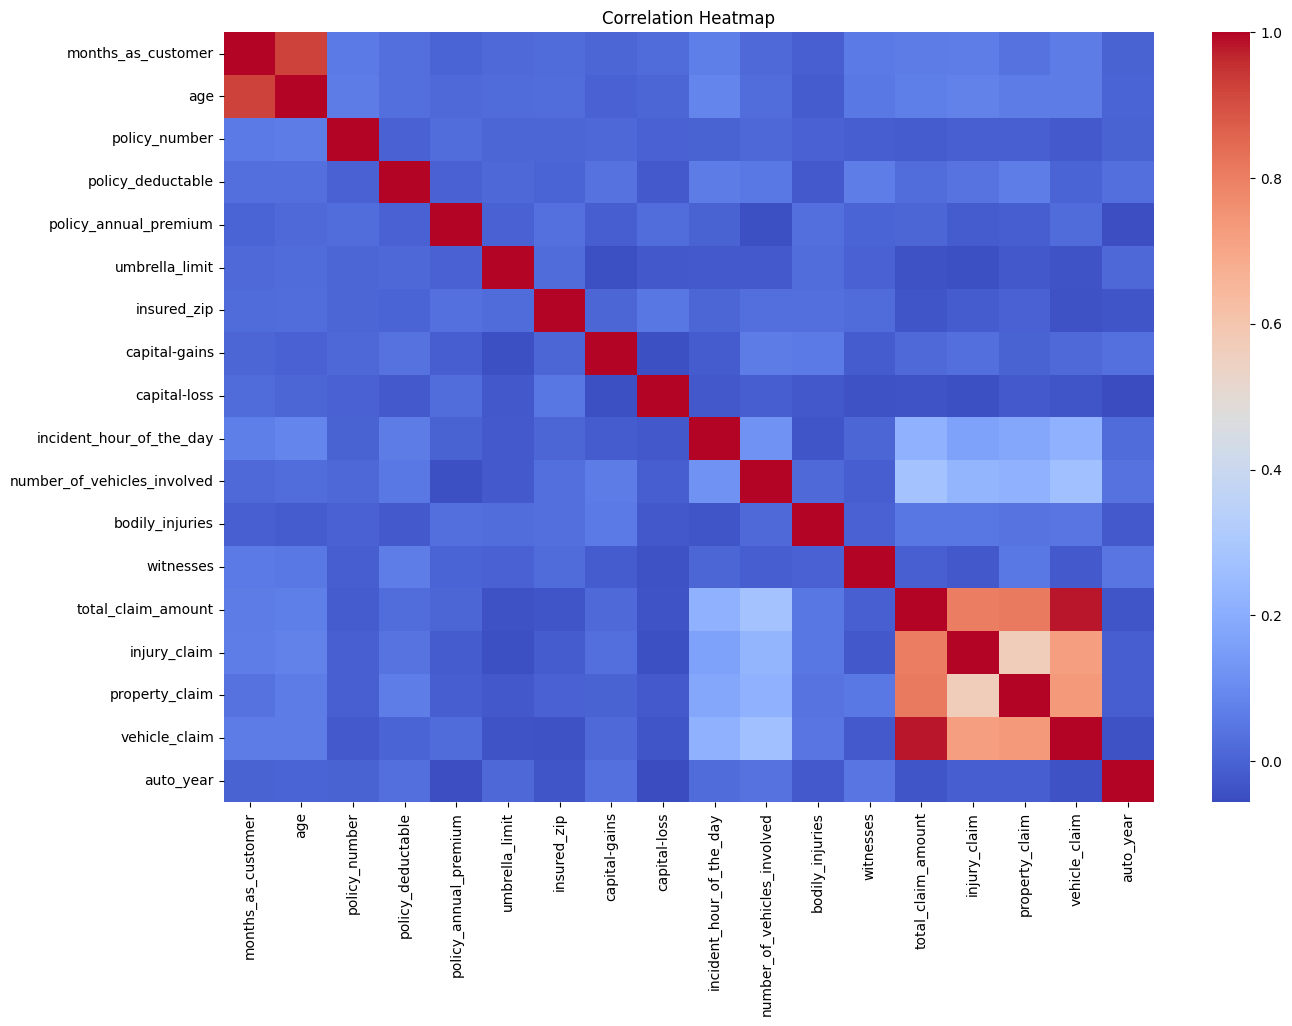

In [27]:
plt.figure(figsize=(15,10))

numeric_df = data.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [28]:
data.drop_duplicates(inplace=True)

In [29]:
#Numerical Columns

for col in numerical_cols:
  data[col].fillna(data[col].median(), inplace=True)

In [30]:
#Categorical Columns

for col in categorical_cols:
 data[col].fillna(data[col].mode()[0], inplace=True)

In [31]:
data.replace('?', np.nan, inplace=True)

In [32]:
#feature engineering
data['policy_bind_date'] = pd.to_datetime(data['policy_bind_date'])
data['incident_date'] = pd.to_datetime(data['incident_date'])

In [33]:
data['policy_duration_days'] = (
data['incident_date'] - data['policy_bind_date']
).dt.days

In [34]:
current_year = 2025

data['vehicle_age'] = current_year - data['auto_year']

In [35]:
data['claim_ratio'] = (
data['total_claim_amount'] / data['policy_annual_premium']
)

In [36]:
data['injury_severity_score'] = (
data['injury_claim'] +
data['bodily_injuries'] * 1000
)

In [37]:
data.drop(['policy_bind_date', 'incident_date'], axis=1, inplace=True)

In [38]:
data['fraud_reported'] = data['fraud_reported'].map({'Y':1, 'N':0})

In [39]:
X = data.drop('fraud_reported', axis=1)

y = data['fraud_reported']

In [40]:
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print(categorical_cols)

['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


In [41]:
data['fraud_reported'] = data['fraud_reported'].map({
    'Y': 1,
    'N': 0
})

In [42]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:

    if col != 'fraud_reported':

        le = LabelEncoder()

        data[col] = le.fit_transform(data[col].astype(str))

        label_encoders[col] = le

In [43]:
print(data.dtypes)

months_as_customer               int64
age                              int64
policy_number                    int64
policy_state                     int64
policy_csl                       int64
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                      int64
insured_education_level          int64
insured_occupation               int64
insured_hobbies                  int64
insured_relationship             int64
capital-gains                    int64
capital-loss                     int64
incident_type                    int64
collision_type                   int64
incident_severity                int64
authorities_contacted            int64
incident_state                   int64
incident_city                    int64
incident_location                int64
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
property_damage          

In [44]:
X = data.drop('fraud_reported', axis=1)

y = data['fraud_reported']

In [45]:
# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("Scaling Completed Successfully!")

Scaling Completed Successfully!


In [46]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,months_as_customer,age,policy_number,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,policy_duration_days,vehicle_age,claim_ratio,injury_severity_score
0,1.078140,0.990836,-0.095953,1.187173,0.060937,-0.222383,0.616705,-0.479476,-0.489529,1.076953,...,-0.189283,1.165505,0.749653,0.856466,-1.645743,-0.183440,-1.727743,0.183440,0.289396,-0.183635
1,0.208995,0.334073,-0.791527,-0.016856,0.060937,1.412784,-0.242521,1.697980,-0.461008,1.076953,...,-1.363822,-1.372696,-1.823346,0.360539,-0.657470,0.315491,-0.599288,-0.315491,-1.605237,-1.533684
2,-0.608002,-1.088913,0.550566,1.187173,-1.182668,1.412784,0.642233,1.697980,-0.984885,-0.928546,...,0.054644,-0.736072,-0.785565,-0.631315,0.959702,0.315491,0.202176,-0.315491,-0.781631,0.255683
3,0.452355,0.224613,-1.239334,-1.220886,0.060937,1.412784,0.652886,2.133471,1.491682,-0.928546,...,-0.224130,-0.219722,0.677607,-0.879279,1.319074,1.479664,1.585371,-1.479664,0.041054,-0.217737
4,0.208995,0.552994,-0.695834,-1.220886,1.304542,-0.222383,1.341980,2.133471,1.527808,1.076953,...,-1.257232,-1.399654,-1.768252,-1.623169,1.049545,0.648112,-1.669644,-0.648112,-1.610558,-1.429371


In [47]:
# Clean target column first

data['fraud_reported'] = (
    data['fraud_reported']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Convert target values
data['fraud_reported'] = data['fraud_reported'].map({
    'Y': 1,
    'N': 0
})

# Check for missing values
print(data['fraud_reported'].isnull().sum())

# Display target distribution
print(data['fraud_reported'].value_counts())

1000
Series([], Name: count, dtype: int64)


In [48]:
print(data['fraud_reported'].unique())

[nan]


In [49]:
import pandas as pd

df = pd.read_csv("fraud_insurance_claims.csv")

In [50]:
print(df['fraud_reported'].unique())

['Y' 'N']


In [51]:
df['fraud_reported'] = df['fraud_reported'].replace({
    'Y': 1,
    'N': 0
})

In [52]:
print(df['fraud_reported'].value_counts())

print(df['fraud_reported'].isnull().sum())

fraud_reported
0    753
1    247
Name: count, dtype: int64
0


In [53]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target column if present
if 'fraud_reported' in categorical_cols:
    categorical_cols.remove('fraud_reported')

print(categorical_cols)

['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


In [54]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

In [55]:
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])

df['incident_date'] = pd.to_datetime(df['incident_date'])

# Feature Engineering
df['policy_duration_days'] = (
    df['incident_date'] - df['policy_bind_date']
).dt.days

# Drop original date columns
df.drop(['policy_bind_date', 'incident_date'], axis=1, inplace=True)

In [56]:
X = df.drop('fraud_reported', axis=1)

y = df['fraud_reported']

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (800, 37)
Test Shape: (200, 37)


In [67]:
# Save Training Columns

training_columns = X.columns.tolist()

joblib.dump(
    training_columns,
    "training_columns.pkl"
)

print("Training Columns Saved!")

Training Columns Saved!


In [59]:
# ============================================
# Apply SMOTE for Class Balancing
# ============================================

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
fraud_reported
0    602
1    198
Name: count, dtype: int64



After SMOTE:
fraud_reported
0    602
1    602
Name: count, dtype: int64


In [60]:
# ============================================
# RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [61]:
# ============================================
# RANDOM FOREST PREDICTION
# ============================================

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [62]:
# ============================================
# RANDOM FOREST EVALUATION
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Random Forest Precision:",
      precision_score(y_test, rf_pred))

print("Random Forest Recall:",
      recall_score(y_test, rf_pred))

print("Random Forest F1 Score:",
      f1_score(y_test, rf_pred))

print("Random Forest ROC AUC:",
      roc_auc_score(y_test, rf_prob))

print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.81
Random Forest Precision: 0.6341463414634146
Random Forest Recall: 0.5306122448979592
Random Forest F1 Score: 0.5777777777777777
Random Forest ROC AUC: 0.8355183132855791

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       151
           1       0.63      0.53      0.58        49

    accuracy                           0.81       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.80      0.81      0.80       200



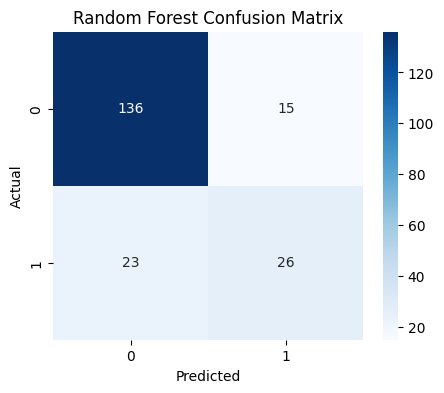

In [63]:
# ============================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [64]:
# ============================================
# HANDLE CLASS IMBALANCE USING SMOTE
# ============================================

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
fraud_reported
0    602
1    198
Name: count, dtype: int64

After SMOTE:
fraud_reported
0    602
1    602
Name: count, dtype: int64


In [65]:
# ============================================
# XGBOOST MODEL
# ============================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [66]:
# ============================================
# SAVE MODEL FILES
# ============================================

import joblib

joblib.dump(
    xgb_model,
    "xgboost_fraud_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

print("PKL Files Saved Successfully!")

PKL Files Saved Successfully!
